In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuro el estilo general de los gráficos
sns.set_theme(style="whitegrid")

# Subo un nivel (../) y entro a la carpeta de la primera actividad
ruta_datos = '../Limpieza-Visualizacion/data/processed/df_financiero_limpio.csv'
df = pd.read_csv(ruta_datos)

# Me aseguro de que la columna fecha sea tipo datetime
df['fecha'] = pd.to_datetime(df['fecha'])

df.head()

,precio_usd,fecha,nuevos_usuarios,volumen_depositos_usd,retorno_diario
0,67387.661682,2026-04-04,152,52590.41,0.000000
1,67305.532706,2026-04-05,485,54862.98,-0.001219
2,67194.731024,2026-04-05,485,54862.98,-0.001646
3,67097.649997,2026-04-05,485,54862.98,-0.001445
4,67159.488410,2026-04-05,485,54862.98,0.000922


Problema a visualizar: ¿Cómo se comportó el precio de Bitcoin en el periodo de 90 días evaluado?

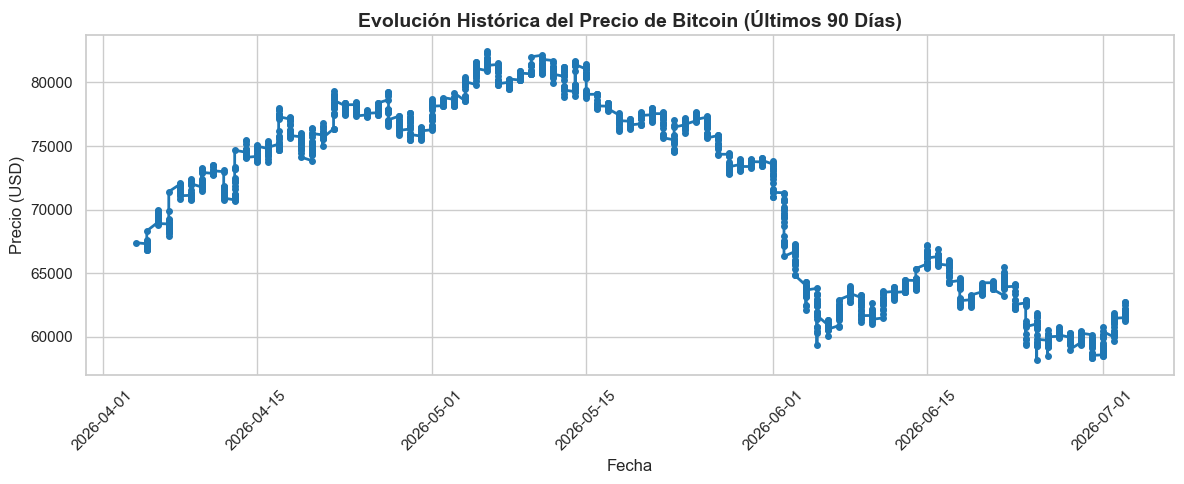

In [3]:
# Gráfico de líneas para ver la evolución del precio de BTC
plt.figure(figsize=(12, 5))

# Personalizo grosor (linewidth), estilo de línea y marcador
plt.plot(df['fecha'], df['precio_usd'], color='#1f77b4', linewidth=2, linestyle='-', marker='o', markersize=4)

# Etiquetas y títulos claros
plt.title('Evolución Histórica del Precio de Bitcoin (Últimos 90 Días)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)

# Roto las fechas para que no se encimen
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Problema a visualizar: ¿Hay más volumen de depósitos en los días con rendimiento positivo (alcistas) o negativo (bajistas)? Como no tenemos la categoría explícita, primero la voy a derivar.

C:\Users\ivan3\AppData\Local\Temp\ipykernel_25740\439424371.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_agrupado, x='tendencia_dia', y='volumen_depositos_usd', palette=colores)


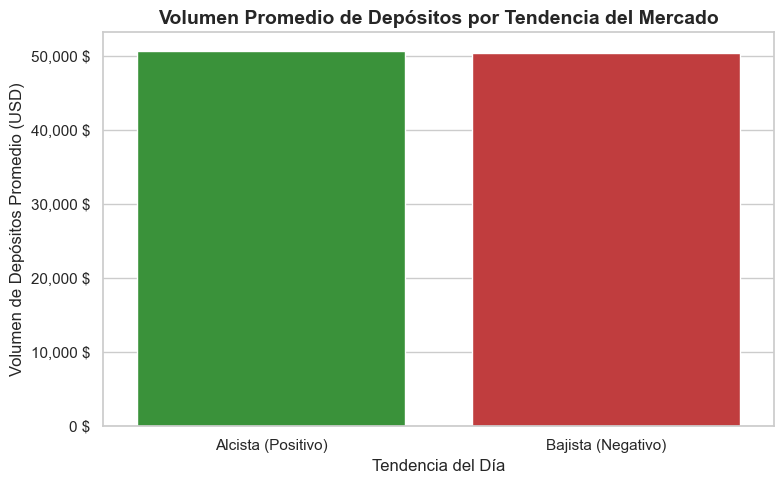

In [4]:
# Creo una nueva columna categórica para identificar si el día fue de ganancias o pérdidas
df['tendencia_dia'] = df['retorno_diario'].apply(lambda x: 'Alcista (Positivo)' if x > 0 else 'Bajista (Negativo)')

# Calculo el promedio de depósitos por cada tendencia
df_agrupado = df.groupby('tendencia_dia')['volumen_depositos_usd'].mean().reset_index()

plt.figure(figsize=(8, 5))

# Uso un gráfico de barras personalizando colores según la categoría (verde para alcista, rojo para bajista)
colores = ['#2ca02c' if tendencia == 'Alcista (Positivo)' else '#d62728' for tendencia in df_agrupado['tendencia_dia']]
sns.barplot(data=df_agrupado, x='tendencia_dia', y='volumen_depositos_usd', palette=colores)

plt.title('Volumen Promedio de Depósitos por Tendencia del Mercado', fontsize=14, fontweight='bold')
plt.xlabel('Tendencia del Día', fontsize=12)
plt.ylabel('Volumen de Depósitos Promedio (USD)', fontsize=12)

# Formateo el eje Y para que parezca dinero
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} $".format(int(x))))

plt.tight_layout()
plt.show()

Problema a visualizar: ¿Existe una relación entre qué tan fuerte es el cambio porcentual diario (volatilidad) y la cantidad de nuevos usuarios que se registran?

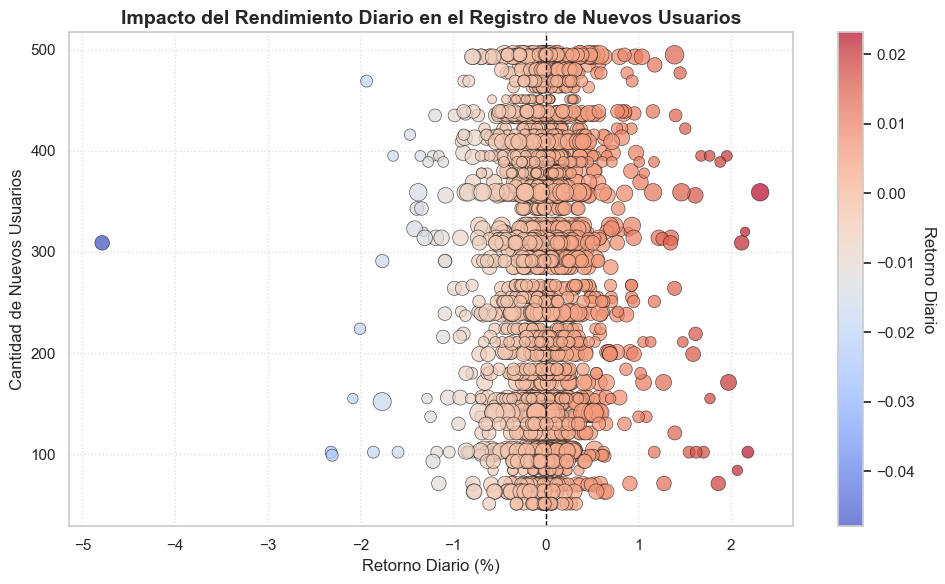

In [5]:
plt.figure(figsize=(10, 6))

# Uso dispersión. El tamaño de los puntos (s) dependerá del volumen de depósitos para dar más contexto (Gráfico de burbujas)
scatter = plt.scatter(x=df['retorno_diario'] * 100, # Lo paso a porcentaje
                      y=df['nuevos_usuarios'], 
                      s=df['volumen_depositos_usd'] / 500, # Escalo el tamaño
                      c=df['retorno_diario'], # El color dependerá del retorno
                      cmap='coolwarm', # Azul para negativo, rojo para positivo
                      alpha=0.7, edgecolors='k', linewidth=0.5)

plt.title('Impacto del Rendimiento Diario en el Registro de Nuevos Usuarios', fontsize=14, fontweight='bold')
plt.xlabel('Retorno Diario (%)', fontsize=12)
plt.ylabel('Cantidad de Nuevos Usuarios', fontsize=12)

# Añado una línea vertical en 0 para separar días de pérdidas y ganancias
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# Agrego la barra de color a la derecha para explicar qué significa el color
cbar = plt.colorbar(scatter)
cbar.set_label('Retorno Diario', rotation=270, labelpad=15)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


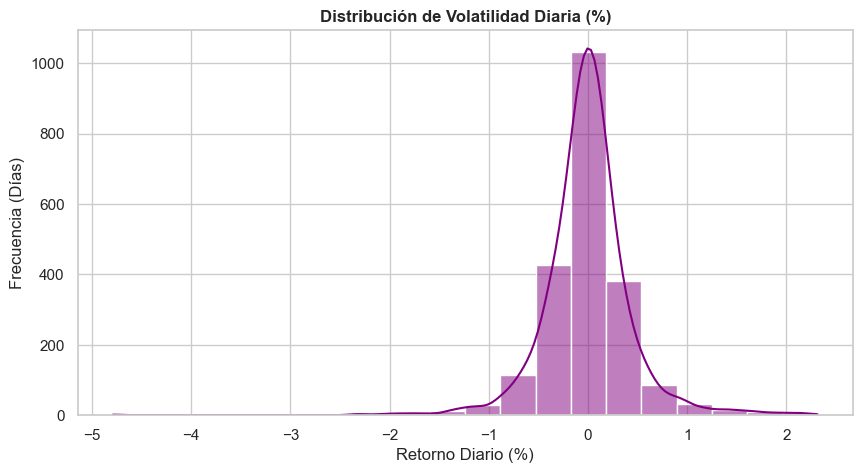

C:\Users\ivan3\AppData\Local\Temp\ipykernel_25740\1875528377.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tendencia_dia', y='nuevos_usuarios', palette={'Alcista (Positivo)': '#2ca02c', 'Bajista (Negativo)': '#d62728'})


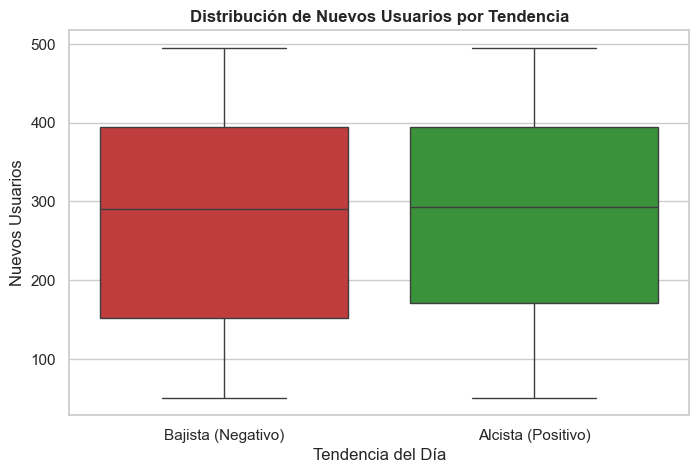

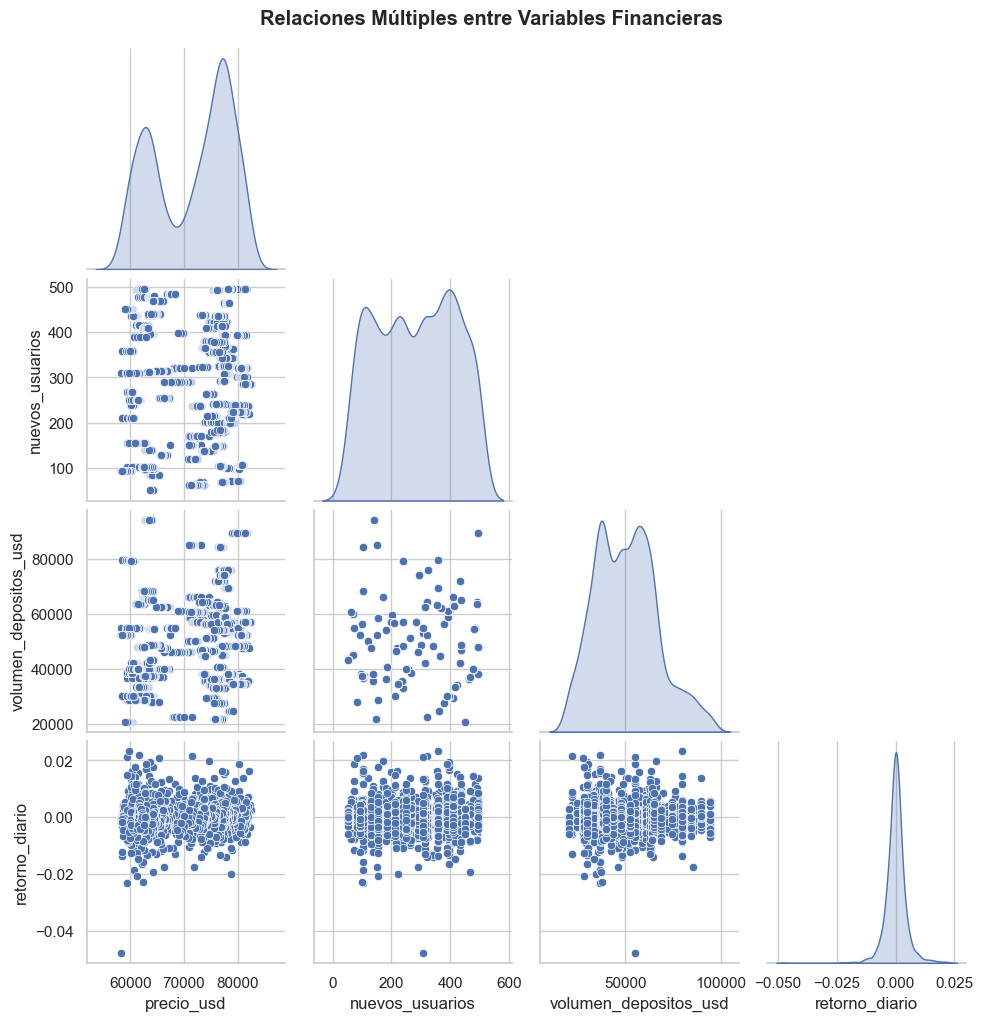

In [6]:
%pip install plotly
%pip install nbformat  

# 1. Histograma: Distribución de los retornos diarios (volatilidad)
plt.figure(figsize=(10, 5))
sns.histplot(df['retorno_diario'] * 100, bins=20, kde=True, color='purple')
plt.title('Distribución de Volatilidad Diaria (%)', fontweight='bold')
plt.xlabel('Retorno Diario (%)')
plt.ylabel('Frecuencia (Días)')
plt.show()

# 2. Boxplot: Dispersión de nuevos usuarios según la tendencia del mercado
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='tendencia_dia', y='nuevos_usuarios', palette={'Alcista (Positivo)': '#2ca02c', 'Bajista (Negativo)': '#d62728'})
plt.title('Distribución de Nuevos Usuarios por Tendencia', fontweight='bold')
plt.xlabel('Tendencia del Día')
plt.ylabel('Nuevos Usuarios')
plt.show()

# 3. Pairplot: Vista general de todas las relaciones numéricas
# Selecciono solo las columnas numéricas relevantes para no saturar el gráfico
vars_numericas = ['precio_usd', 'nuevos_usuarios', 'volumen_depositos_usd', 'retorno_diario']
sns.pairplot(df[vars_numericas], corner=True, diag_kind='kde')
plt.suptitle('Relaciones Múltiples entre Variables Financieras', y=1.02, fontweight='bold')
plt.show()

# Interpretación : El histograma nos mostrará si los retornos siguen una distribución normal o tienen sesgo. 
# El boxplot ayuda a ver si los días alcistas traen más usuarios atípicos (outliers).

C:\Users\ivan3\AppData\Local\Temp\ipykernel_25740\1881983299.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='tendencia_dia', palette='viridis', ax=axes[0])


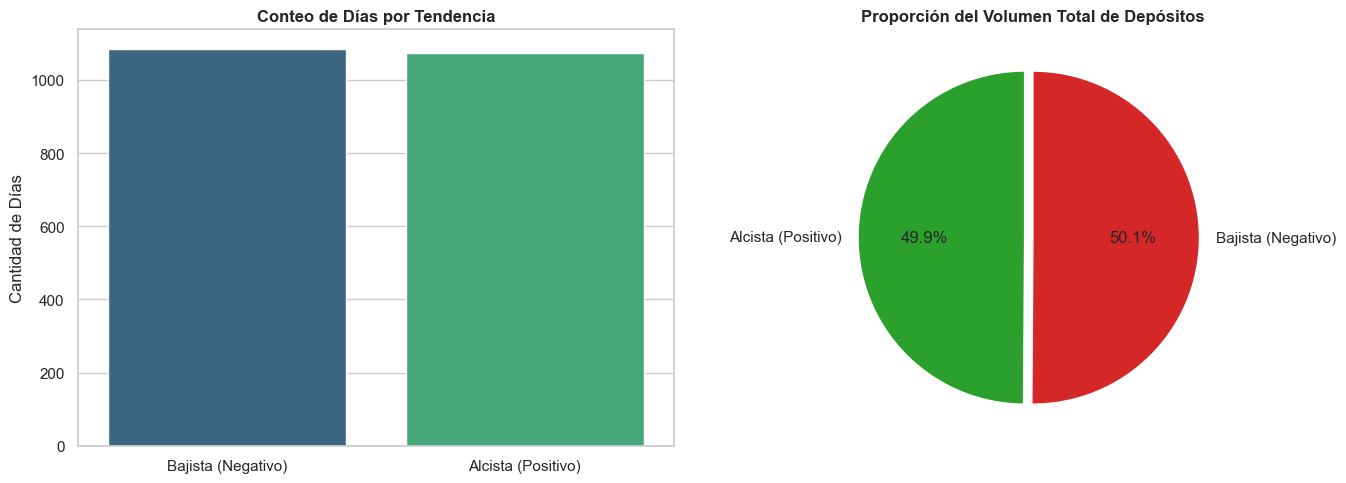

In [7]:
# 1. Countplot: Frecuencia de días alcistas vs bajistas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='tendencia_dia', palette='viridis', ax=axes[0])
axes[0].set_title('Conteo de Días por Tendencia', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad de Días')

# 2. Pie Chart: Proporción del volumen TOTAL movido según la tendencia
# Agrupo el volumen total sumado, no el promedio
volumen_total = df.groupby('tendencia_dia')['volumen_depositos_usd'].sum()
axes[1].pie(volumen_total, labels=volumen_total.index, autopct='%1.1f%%', colors=['#2ca02c', '#d62728'], startangle=90, explode=[0.05, 0])
axes[1].set_title('Proporción del Volumen Total de Depósitos', fontweight='bold')

plt.tight_layout()
plt.show()

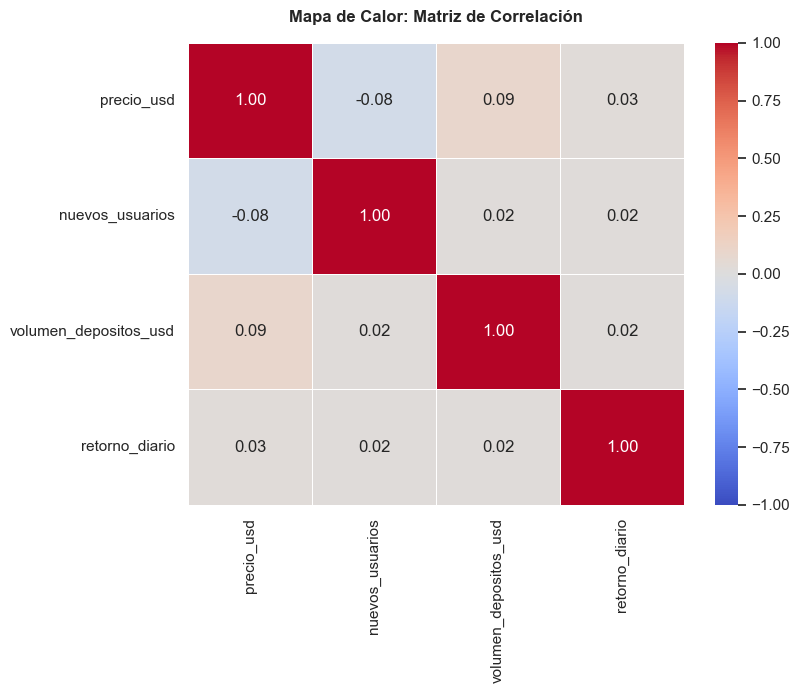

In [8]:
plt.figure(figsize=(8, 6))

# Calculo la matriz de correlación de Pearson
matriz_corr = df[vars_numericas].corr()

# Genero el heatmap con la paleta coolwarm (rojo para correlación positiva, azul para negativa)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Mapa de Calor: Matriz de Correlación', fontweight='bold', pad=15)
plt.show()

# Interpretación: Aquí puedo confirmar numéricamente si el precio alto atrae más usuarios (correlación positiva cercana a 1)
# o si no tienen relación estadística (cercana a 0).

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Defino el layout del dashboard (2 filas, 2 columnas)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Evolución del Precio BTC (USD)", "Usuarios vs Volumen de Depósitos", 
                    "Volatilidad Diaria (%)", "Proporción de Días (Alcista vs Bajista)"),
    specs=[[{"type": "scatter"}, {"type": "scatter"}],
           [{"type": "bar"}, {"type": "domain"}]] # domain es necesario para pie charts en plotly
)

# 1. Gráfico de Líneas (Arriba Izquierda)
fig.add_trace(go.Scatter(x=df['fecha'], y=df['precio_usd'], mode='lines', name='Precio BTC', line=dict(color='blue')), row=1, col=1)

# 2. Dispersión Interactiva (Arriba Derecha)
fig.add_trace(go.Scatter(x=df['nuevos_usuarios'], y=df['volumen_depositos_usd'], mode='markers', 
                         marker=dict(size=8, color=df['retorno_diario'], colorscale='RdBu', showscale=True),
                         text=df['fecha'], name='Usuarios vs Depósitos'), row=1, col=2)

# 3. Gráfico de Barras - Volatilidad (Abajo Izquierda)
colores_retorno = ['green' if val > 0 else 'red' for val in df['retorno_diario']]
fig.add_trace(go.Bar(x=df['fecha'], y=df['retorno_diario']*100, marker_color=colores_retorno, name='Retorno %'), row=2, col=1)

# 4. Gráfico de Pastel (Abajo Derecha)
conteos = df['tendencia_dia'].value_counts()
fig.add_trace(go.Pie(labels=conteos.index, values=conteos.values, marker_colors=['red', 'green'], hole=0.4), row=2, col=2)

# Configuración final de diseño
fig.update_layout(height=800, width=1100, title_text="Dashboard Financiero: Comportamiento de Usuarios vs Mercado", title_x=0.5, showlegend=False)

fig.show()